# NLP - EDA

# Comprehensive Exploratory Data Analysis (EDA)
we must act as data detectives. Real-world data is rarely perfect. 

In this notebook, we will explore a web-crawled medical directory dataset. It consists of two parts:
1. **Doctors Dataset**: Profiles, specialties, and overall ratings.
2. **Comments Dataset**: Patient reviews, text lengths, and sentiment labels.

Let's dive in and see what secrets this raw data holds!

In [ ]:
# Install package
# !pip install python-bidi
# !pip install pytest-warnings

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import arabic_reshaper
from bidi.algorithm import get_display
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Arial'] # Better support for Persian text

## Part 1: Exploring the Doctors Dataset 🩺
First, let's load the doctors' profiles. We want to know what kind of doctors we have, how complete their profiles are, and how patients rate them overall.

In [22]:
# create Path of folder's data
PROJECT_FOLDER = os.path.dirname(os.path.dirname(os.getcwd()))
DATA_FOLDER = r"data\raw\Training & Education Data\NLP"
PATH = os.path.join(PROJECT_FOLDER, DATA_FOLDER)
PATH

'c:\\Mohsen Folder\\Ai Bootcamp\\Ai Bootcamp\\data\\raw\\Training & Education Data\\NLP'

In [23]:
# Load the canonical doctors dataset
PATH_DOCTORS_RAW_CANONICAL = os.path.join(PATH, "doctors_raw_canonical.csv")
df_doctors = pd.read_csv(PATH_DOCTORS_RAW_CANONICAL)
df_doctors.head()

,doctor_id,source_file,profile_url,nice_id,name,specialty,medical_code,verified,followers_count,reviews_count,rating_percent,rating_score_5,biography,office_count,comments_count_in_file,selected_source_file,all_source_files,source_files_count
0,100246,پوست_و_مو_doctor_337.json,https://nobat.ir/3023,3023,دکتر علیرضا تقی زاده,متخصص پوست ، مو و زیبایی,متخصصشماره نظام: ۴۸۸۷۵,False,NaN,205.0,86.0,4.3,NaN,1.0,134.0,پوست_و_مو_doctor_337.json,پوست_و_مو_doctor_337.json,1.0
1,100332,ارتوپدی_doctor_203.json,https://nobat.ir/doctor/%D8%AF%DA%A9%D8%AA%D8%...,3034,دکتر کورش فاتح,متخصص ارتوپدی - تعویض مفصل,متخصصشماره نظام: ۴۲۲۶۸,False,NaN,256.0,86.0,4.3,NaN,3.0,169.0,ارتوپدی_doctor_203.json,ارتوپدی_doctor_203.json,1.0
2,102091,پوست_و_مو_doctor_369.json,https://nobat.ir/dresfahani,dresfahani,دکتر منصور اصفهانی,متخصص پوست ، مو و لیزر,متخصصشماره نظام: ۳۲۲۸۲,False,NaN,464.0,90.0,4.5,اینجانب دکتر منصور اصفهانی متولد شهر زیبای رشت...,2.0,257.0,پوست_و_مو_doctor_369.json,پوست_و_مو_doctor_369.json,1.0
3,102727,زنان_و_زایمان_doctor_92.json,https://nobat.ir/drlavasani,drlavasani,دکتر زهره لواسانی,متخصص زنان و زایمان ( فلوشیپ نازایی )، IVF و ل...,فلوشیپشماره نظام: ۶۴۷۳۱,False,NaN,843.0,90.0,4.5,درباره من – دکتر زهره لواسانی – جراح و متخصص ز...,1.0,243.0,زنان_و_زایمان_doctor_92.json,زنان_و_زایمان_doctor_92.json,1.0
4,103130,ارتوپدی_doctor_195.json,https://nobat.ir/3258,3258,دکتر مسعود یاوری,فلوشیپ جراحی دست,فلوشیپشماره نظام: ۳۱۱۳۲,False,NaN,636.0,94.0,4.7,دکتر مسعود یاوری: استاد تمام دانشگاه، دبیر انج...,1.0,232.0,ارتوپدی_doctor_195.json,ارتوپدی_doctor_195.json,1.0


In [27]:
print("Total Doctor".center(40,"-"))
print(f"Total Doctors: {len(df_doctors):,}")
print("-" * 30)


--------------Total Doctor--------------
Total Doctors: 569
------------------------------


In [31]:
# Check for missing values (Completeness of Profiles)
print("Missing Data in Doctor Profiles:")
missing_data = df_doctors.isnull().sum()
print(missing_data[missing_data > 0])

Missing Data in Doctor Profiles:
followers_count           569
reviews_count              18
rating_percent             11
rating_score_5             11
biography                 147
office_count                1
comments_count_in_file      1
selected_source_file        1
all_source_files            1
source_files_count          1
dtype: int64


In [32]:
# Specific check for Biographies (Empty strings vs Nulls)
empty_bio = (df_doctors['biography'].astype(str).str.strip() == "").sum()
print(f"\nDoctors missing a biography completely: {empty_bio} ({empty_bio/len(df_doctors)*100:.1f}%)")


Doctors missing a biography completely: 0 (0.0%)


**Insight:** 
While basic info like names and specialties are 100% complete, about **25.8% of doctors have no biography**, and we have no `followers_count` data at all.

Let's look at the **Specialties** and **Ratings**.

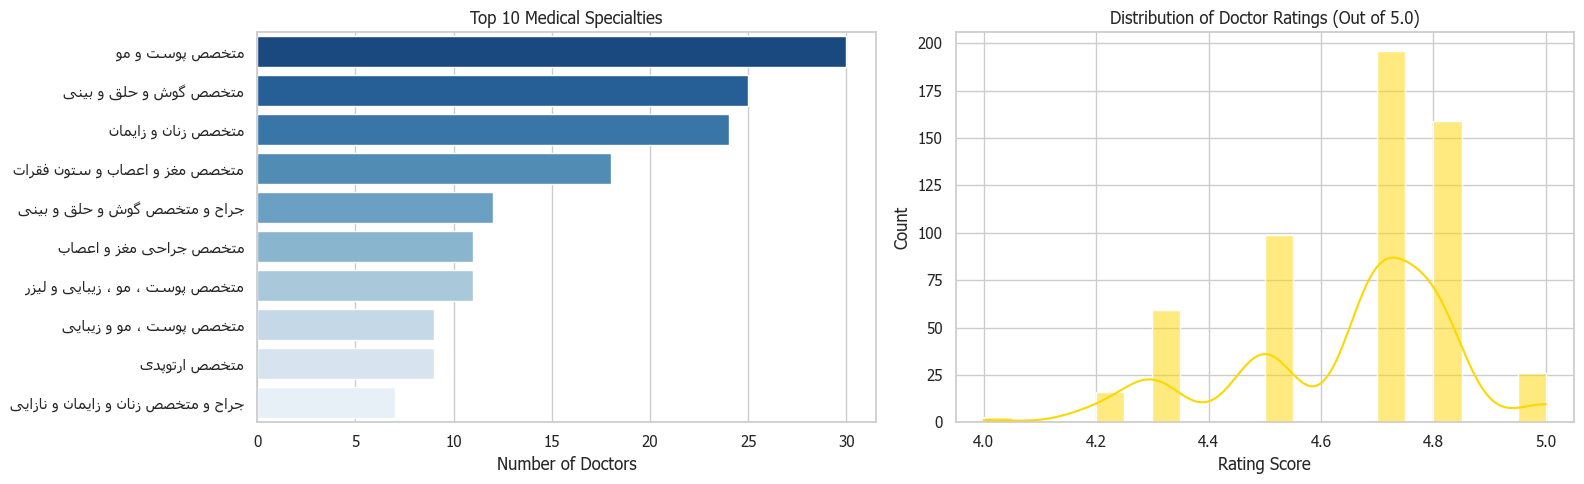

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Top 10 Specialties
top_specialties = df_doctors['specialty'].value_counts().head(10)

rtl_labels = [
    get_display(arabic_reshaper.reshape(label))
    for label in top_specialties.index
]

sns.barplot(y=rtl_labels, x=top_specialties.values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 10 Medical Specialties")
axes[0].set_xlabel("Number of Doctors")

# 2. Doctor Ratings Distribution (Out of 5.0)
sns.histplot(df_doctors['rating_score_5'].dropna(), bins=20, kde=True, ax=axes[1], color="gold")
axes[1].set_title("Distribution of Doctor Ratings (Out of 5.0)")
axes[1].set_xlabel("Rating Score")

plt.tight_layout()
plt.show()



In [35]:
print("Doctor Numeric Stats:")
print(df_doctors[['reviews_count', 'rating_score_5', 'office_count']].describe().loc[['mean', 'min', '50%', 'max']])

Doctor Numeric Stats:
      reviews_count  rating_score_5  office_count
mean     264.967332        4.646595      1.473592
min        1.000000        4.000000      1.000000
50%      156.000000        4.700000      1.000000
max     2663.000000        5.000000     13.000000


In [36]:
print("Min rating_score_5 =", df_doctors["rating_score_5"].min())

print("Max office_count =", df_doctors["office_count"].max())


Min rating_score_5 = 4.0
Max office_count = 13.0


**Insight:**
1. **Specialties:** "متخصص پوست و مو" (Dermatology), ENT, and Gynecology are the most common specialties in our dataset.
2. **Ratings:** The ratings are highly skewed toward the positive! The average rating is **4.65/5.0**, and the median is **4.7**. People generally leave good ratings.

---
## Part 2: Exploring the Comments Dataset
Now let's load the comments. We have around **67,000** patient reviews. 
Let's see how labels (-1, 0, 1) map to star ratings (0.0 to 5.0).


In [37]:
"comments_raw_canonical".upper()

'COMMENTS_RAW_CANONICAL'

In [41]:
# Load the canonical comments dataset
PATH_COMMENTS_RAW_CANONICAL = os.path.join(PATH, "comments_raw_canonical.csv")
df_comments = pd.read_csv(PATH_COMMENTS_RAW_CANONICAL)

print(f"Total Comments: {len(df_comments):,}")
print(f"Doctors with 0 comments: {len(df_doctors) - df_comments['doctor_id'].nunique()}")

Total Comments: 66,465
Doctors with 0 comments: 24


In [42]:
df_comments.head(3)

,doctor_id,source_file,comment_index_in_file,specialty,text,rate,label,date
0,100246,پوست_و_مو_doctor_337.json,0,متخصص پوست ، مو و زیبایی,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴
1,100246,پوست_و_مو_doctor_337.json,1,متخصص پوست ، مو و زیبایی,زگیل زیر ناخن.تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶
2,100246,پوست_و_مو_doctor_337.json,2,متخصص پوست ، مو و زیبایی,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸


In [43]:
# Map labels to readable names
label_map = {-1: "Negative", 0: "Neutral", 1: "Positive"}
df_comments['label_name'] = df_comments['label'].map(label_map)

# Let's cross-tabulate Label vs. Rating
label_rate_ct = pd.crosstab(df_comments['label_name'], df_comments['rate'])
print("\nCross-Tabulation: Label vs Rating:")
print(label_rate_ct)


Cross-Tabulation: Label vs Rating:
rate         0.0   2.5    5.0
label_name                   
Negative    2742     0      0
Neutral        0  8076      0
Positive       0     0  55647


**Major NLP Discovery:** 
Look at the cross-tabulation! It is perfectly rigid:
* All `Negative (-1)` labels have a `0.0` rating.
* All `Neutral (0)` labels have a `2.5` rating.
* All `Positive (1)` labels have a `5.0` rating.

Let's look at the class imbalance and investigate the **Negative** class.
